# Multiple Andreev reflection and the AC Josephson effect

`didv`/`landauer` above are equilibrium, zero-bias linear-response quantities. A voltage-biased
junction between two superconductors (an SNS junction) instead makes each lead's pairing phase
wind in time, giving rise to multiple Andreev reflections (MAR) and an AC Josephson effect --
the physically meaningful quantity is the time-averaged (DC) current $I_{dc}(V)$.
`Heterostructure.get_dc_current(voltage)` computes this with the Floquet-Keldysh formalism of
San-Jose, Cayao, Prada and Aguado, *New J. Phys.* **15**, 075019 (2013)
([arXiv:1301.4408](https://arxiv.org/abs/1301.4408)). The same routing applies to
`transporttk.localprobe.LocalProbe`: when *both* the STM-like probe lead and the sample are
superconducting, `didv`/`get_kappa` automatically switch from the ordinary scattering-matrix
formula to this same Floquet-Keldysh machinery, since there is no longer a normal lead to define
a reflection amplitude against. Both cases are considerably more expensive than the equilibrium
case (each point runs a full Floquet sideband sweep), so the grids below are kept deliberately
coarse.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

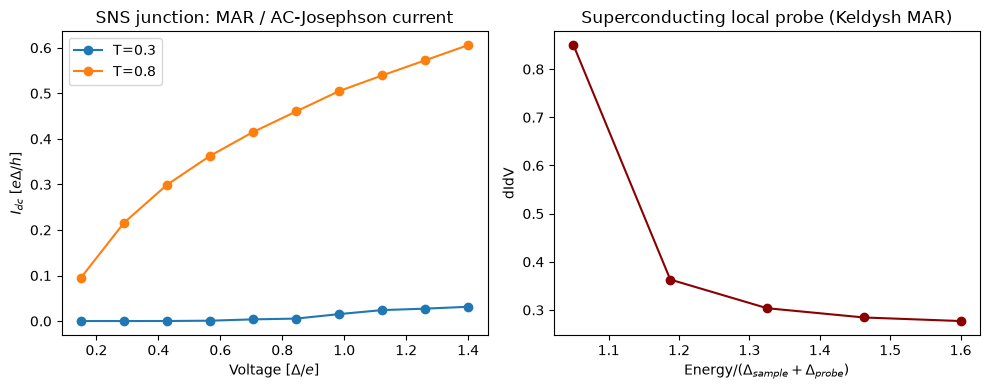

In [2]:
# --- SNS junction: DC current vs bias voltage (MAR steps) ---
g = geometry.chain()
h = g.get_hamiltonian()
delta = 0.1
h1 = h.copy() ; h1.add_swave(delta) # left superconducting lead
h2 = h.copy() ; h2.add_swave(delta) # right superconducting lead

vs = np.linspace(0.15,1.4,10)*delta # deliberately coarse bias grid (expensive);
                                     # avoids the very-low-bias region where the
                                     # Floquet sideband sum converges too slowly
fig,axs = plt.subplots(1,2,figsize=(10,4))
for T in [0.3,0.8]:
    HT = heterostructures.build(h1,h2)
    HT.set_coupling(T)
    Is = HT.get_iv_curve(vs)
    axs[0].plot(vs/delta,Is,marker="o",label=f"T={T}")
axs[0].set_xlabel(r"Voltage [$\Delta/e$]") ; axs[0].set_ylabel(r"$I_{dc}$ [$e\Delta/h$]")
axs[0].set_title("SNS junction: MAR / AC-Josephson current")
axs[0].legend()

# --- superconducting local (STM-like) probe on a superconducting sample ---
from pyqula.transporttk.localprobe import LocalProbe
hs = g.get_hamiltonian() ; hs.shift_fermi(1.) ; hs.add_swave(delta) # SC sample
lead = geometry.chain().get_hamiltonian() ; lead.shift_fermi(1.) ; lead.add_swave(delta) # SC probe
lp = LocalProbe(hs,lead=lead,delta=1e-3)
lp.T = 0.3
kwargs = dict(nmax=4,nmax_max=12,tol=5e-2) # keep the Floquet sideband sweep cheap
Dsum = 2*delta # onset of single-quasiparticle transport (MAR order n=1)
es = np.linspace(1.05*Dsum,1.6*Dsum,5)
ts = [lp.didv(energy=e,**kwargs) for e in es] # routed through Keldysh automatically
axs[1].plot(es/Dsum,ts,marker="o",c="darkred")
axs[1].set_xlabel(r"Energy/$(\Delta_{sample}+\Delta_{probe})$") ; axs[1].set_ylabel("dIdV")
axs[1].set_title("Superconducting local probe (Keldysh MAR)")
plt.tight_layout()
plt.show()

Sweeping the transparency $T$ of the SNS junction on the same coarse bias grid gives the DC current as a map over the voltage and $T$, each row normalized to its value at the largest voltage so that the shape of $I_{dc}(V)$ can be compared between the tunneling and the transparent regimes.

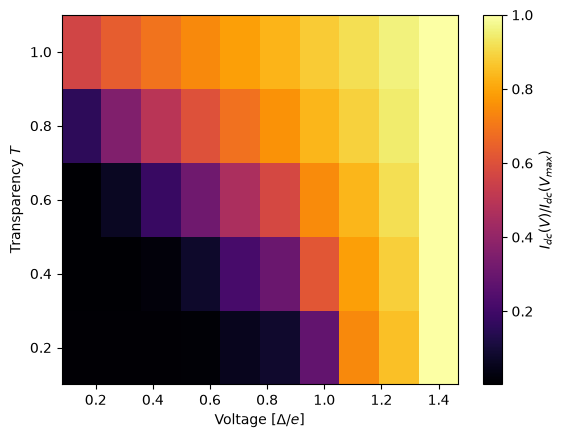

In [3]:
Ts = np.linspace(0.2,1.0,5) # transparencies of the SNS junction
kw_iv = dict(nmax=4,nmax_max=30,tol=2e-2) # a cheaper Floquet sideband sweep
Imap = []
for T in Ts:
    HT = heterostructures.build(h1,h2)
    HT.set_coupling(T)
    Is = np.array(HT.get_iv_curve(vs,**kw_iv)) # DC current on the bias grid above
    Imap.append(Is/Is[-1]) # normalized to the current at the largest voltage

plt.pcolormesh(vs/delta,Ts,np.array(Imap),shading="auto",cmap="inferno")
plt.colorbar(label="$I_{dc}(V)/I_{dc}(V_{max})$")
plt.xlabel(r"Voltage [$\Delta/e$]") ; plt.ylabel("Transparency $T$")
plt.show()